<a href="https://colab.research.google.com/github/MarcGaac/EDA-DSC1105/blob/main/DSC1105_LabFA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




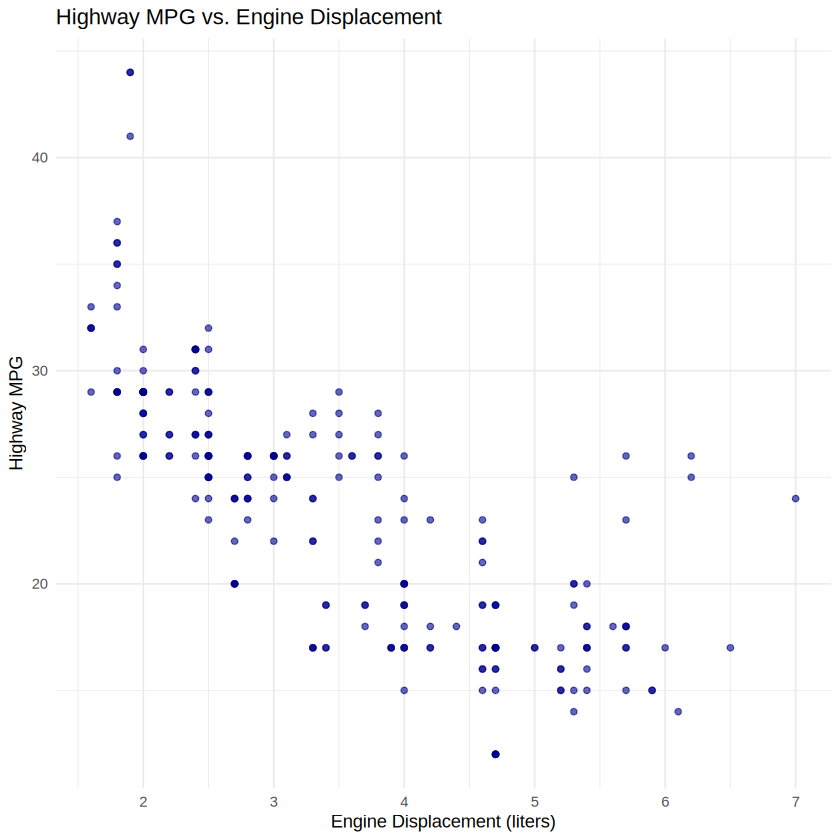


Call:
lm(formula = hwy ~ displ, data = mpg)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.1039 -2.1646 -0.2242  2.0589 15.0105 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  35.6977     0.7204   49.55   <2e-16 ***
displ        -3.5306     0.1945  -18.15   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.836 on 232 degrees of freedom
Multiple R-squared:  0.5868,	Adjusted R-squared:  0.585 
F-statistic: 329.5 on 1 and 232 DF,  p-value: < 2.2e-16


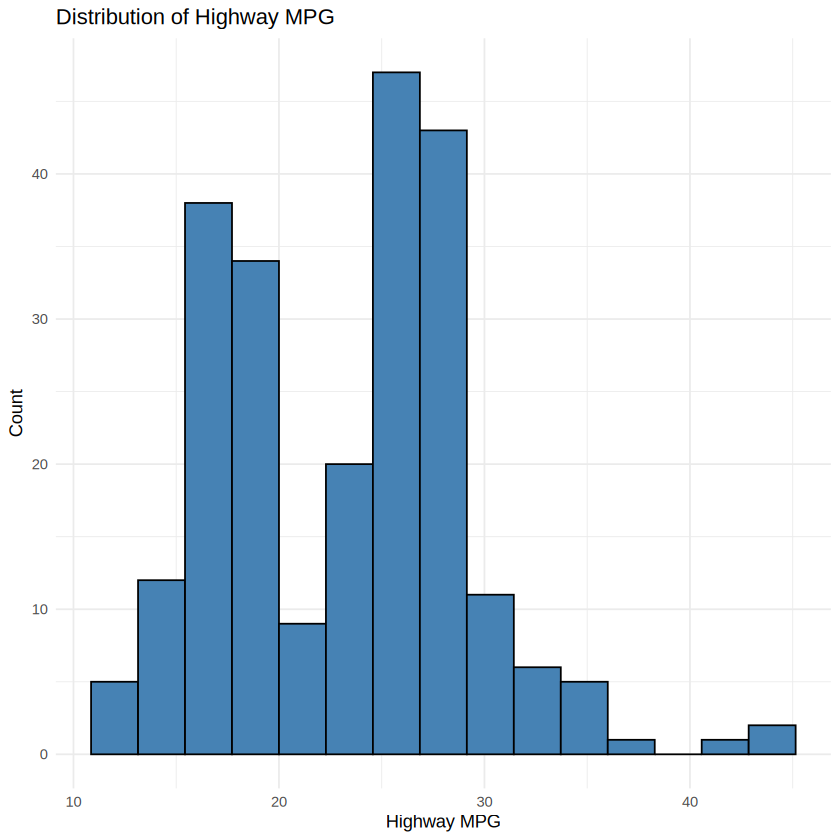


Call:
lm(formula = log(hwy) ~ log(displ), data = mpg)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.43240 -0.08757 -0.01011  0.09514  0.49234 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.76407    0.03364  111.90   <2e-16 ***
log(displ)  -0.54716    0.02726  -20.07   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1578 on 232 degrees of freedom
Multiple R-squared:  0.6345,	Adjusted R-squared:  0.6329 
F-statistic: 402.8 on 1 and 232 DF,  p-value: < 2.2e-16


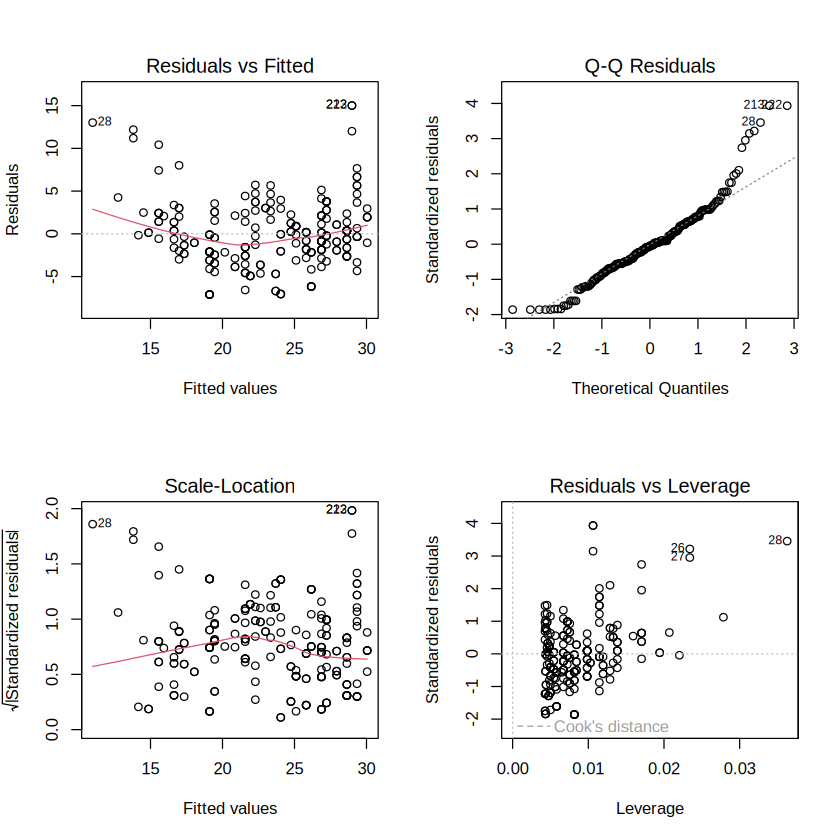

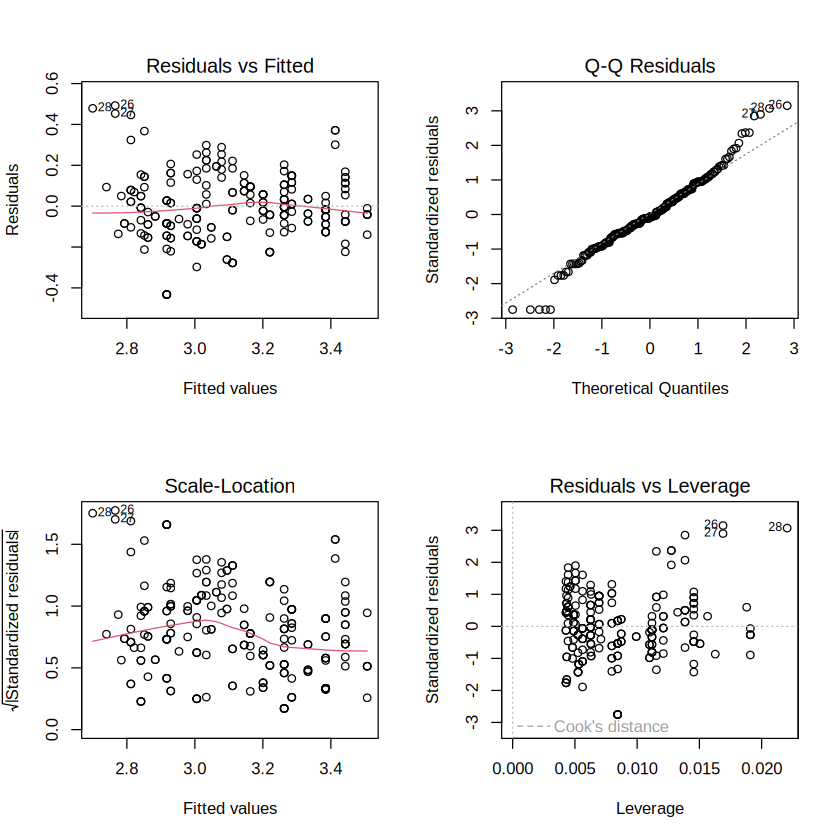

In [ ]:
# Load necessary libraries and dataset
library(ggplot2)
library(dplyr)
data(mpg)

# ==========================================
# PART 1: Exploratory Data Analysis
# ==========================================

# Scatterplot of hwy vs displ
p_scatter <- ggplot(mpg, aes(x = displ, y = hwy)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  theme_minimal() +
  labs(title = "Highway MPG vs. Engine Displacement",
       x = "Engine Displacement (liters)",
       y = "Highway MPG")

# Histogram of hwy
p_hist <- ggplot(mpg, aes(x = hwy)) +
  geom_histogram(bins = 15, fill = "steelblue", color = "black") +
  theme_minimal() +
  labs(title = "Distribution of Highway MPG",
       x = "Highway MPG",
       y = "Count")

print(p_scatter)
print(p_hist)

# ==========================================
# PART 2: Building a Simple Linear Model
# ==========================================

# Fit the simple linear regression model
mpg_model <- lm(hwy ~ displ, data = mpg)

# Display the summary to get coefficients for the equation
summary(mpg_model)

# ==========================================
# PART 3: Model Assumptions and Diagnostics
# ==========================================

# Set up a 2x2 grid for diagnostic plots
par(mfrow = c(2, 2))
# Plot base R diagnostic plots
plot(mpg_model)
# Reset plot layout
par(mfrow = c(1, 1))

# ==========================================
# PART 4: Transformation or Model Critique
# ==========================================

# Apply a log-log transformation to address non-linearity and non-constant variance
mpg_model_log <- lm(log(hwy) ~ log(displ), data = mpg)

# Display the summary of the new model
summary(mpg_model_log)

# Plot diagnostics for the new transformed model
par(mfrow = c(2, 2))
plot(mpg_model_log)
par(mfrow = c(1, 1))


**Part 1: Exploratory Data Analysis**

​Response variable: hwy (highway miles per gallon)

​Explanatory variable: displ (engine displacement in liters)

**Part 2: Building a Simple Linear Model**

The equation for the fitted model is: hwy = 35.698 – 3.531(displ).


Interpretation of the slope: For every 1-liter increase in engine displacement, highway fuel efficiency is expected to drop by 3.531 miles per gallon.


Interpretation of the intercept: A vehicle with an engine size of zero liters would be expected to have a highway fuel efficiency of 35.698 miles per gallon. (Note: Because having an engine size of 0 liters is impossible, the intercept does not have any meaningful implications).

**Part 3: Model Assumptions and Diagnostics**


​Linearity: The assumption of linearity appears to be violated. The "Residuals vs Fitted" plot shows a distinct U-shaped curve rather than a random scatter of points around zero, indicating that the true relationship between displacement and MPG is curved.


​Normality of residuals: The assumption of normality is slightly violated. In the "Normal Q-Q" plot, the residuals trail off at the upper tail (points curve away from the diagonal line), suggesting right-skewed errors.


​Constant variance (homoscedasticity): This assumption is violated. The "Scale-Location" plot shows that the spread of the residuals is wider at lower fitted values and narrower at higher fitted values, meaning the variance is not constant across the range of the data (heteroscedasticity).

**Part 4: Transformation or Model Critique**


Since the assumptions of linearity and constancy of variance have not been satisfied, the basic linear model cannot be used with the original data. Logarithmic transformation is justifiable as the relationship between mileage and displacement is usually described by the proportional function rather than a linear function. The least squares regression model obtained after the transformation appears much better than the one computed earlier: the residuals are distributed around zero much more evenly than before, and the U-shaped distribution disappears.

**Part 5: Reflection**


Through this activity, I learned that engine displacement has a strong negative, but non-linear, relationship with highway fuel efficiency. Larger engines consume more fuel, but the drop in MPG is much steeper for smaller engines than for already-large engines. This highlights exactly why checking model assumptions is critical when working with real-world data: if we had blindly trusted the initial simple linear regression, we would have made inaccurate predictions and drawn flawed conclusions due to underlying heteroscedasticity and non-linearity.